In [1]:
# ==============================================================================
# FASE 0: Installazione delle dipendenze necessarie per l'ambiente Colab
# ==============================================================================
!pip install kagglehub pandas numpy matplotlib opencv-python scikit-learn scikit-image torch torchvision tqdm

In [2]:
# ==============================================================================
# FASE 1: Download del Dataset, Ispezione e Data Cleaning
# ==============================================================================
import os
import kagglehub
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Download automatico del dataset tramite kagglehub
dataset_path = kagglehub.dataset_download("agrigorev/clothing-dataset-full")
print(f"Dataset scaricato con successo in: {dataset_path}")

# Caricamento dei metadati originali
csv_path = os.path.join(dataset_path, "images.csv")
df = pd.read_csv(csv_path)

print("\n--- Informazioni sul Dataset Grezzo ---")
print(f"Totale record iniziali: {len(df)}")
print(f"Colonne disponibili: {df.columns.tolist()}")

# Pulizia dei dati:
# 1. Rimuoviamo i record ambigui ('Not sure') o privi di label per evitare rumore
clean_df = df[df['label'] != 'Not sure'].dropna(subset=['label']).copy()

# 2. Localizziamo la cartella corretta contenente i file fisici delle immagini
if os.path.exists(os.path.join(dataset_path, "images_original")):
    img_folder = os.path.join(dataset_path, "images_original")
elif os.path.exists(os.path.join(dataset_path, "images")):
    img_folder = os.path.join(dataset_path, "images")
else:
    img_folder = dataset_path

def get_full_path(img_id):
    filename = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else str(img_id)
    return os.path.join(img_folder, filename)

clean_df['filepath'] = clean_df['image'].apply(get_full_path)

# 3. Manteniamo esclusivamente le righe con file immagine effettivamente accessibili
clean_df = clean_df[clean_df['filepath'].apply(os.path.exists)].reset_index(drop=True)

print(f"\nImmagini valide e verificate su disco: {len(clean_df)}")

100%|██████████| 6.50G/6.50G [01:06<00:00, 105MB/s]

Extracting files...


Dataset scaricato con successo in: /root/.cache/kagglehub/datasets/agrigorev/clothing-dataset-full/versions/1

--- Informazioni sul Dataset Grezzo ---
Totale record iniziali: 5403
Colonne disponibili: ['image', 'sender_id', 'label', 'kids']

Immagini valide e verificate su disco: 5175


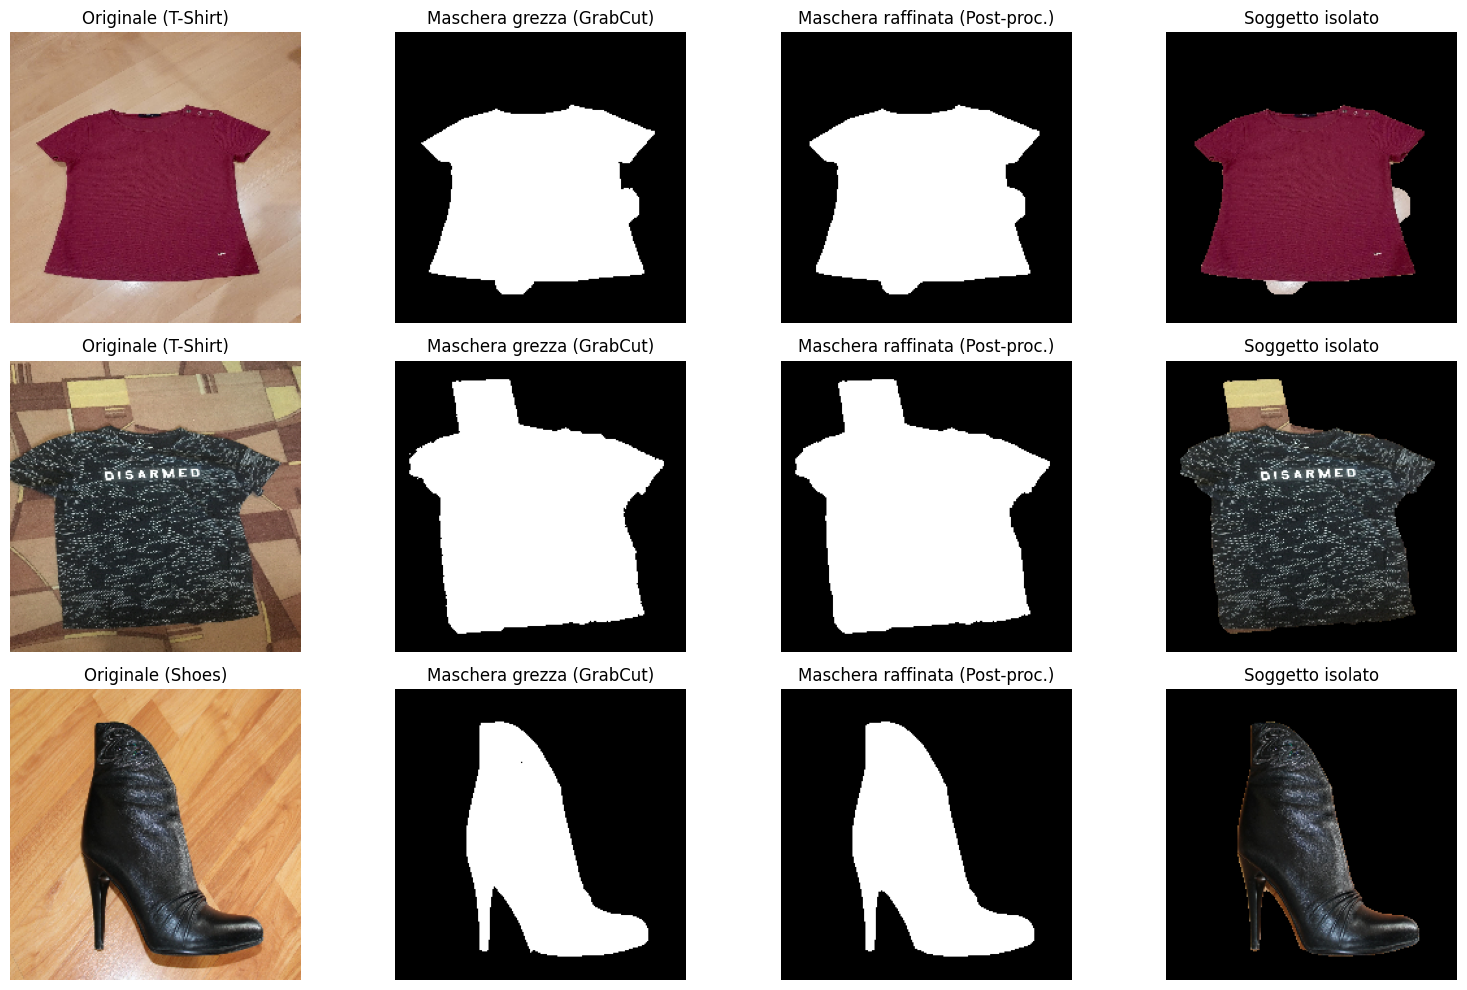

In [3]:
# ==============================================================================
# FASE 2: Preprocessing, Segmentazione (GrabCut) e Post-processing della Maschera
# ==============================================================================
def refine_mask(mask_binary, kernel_size=5):
    """
    Pulisce la maschera binaria grezza prodotta da GrabCut (stage di
    Post-processing della pipeline):
    - Opening (erosione + dilatazione): toglie piccoli puntini di rumore che
      GrabCut a volte marca come foreground per errore.
    - Closing (dilatazione + erosione): richiude piccoli buchi dentro al
      soggetto (es. zone in ombra scambiate per sfondo).
    - Teniamo solo la componente connessa piu' grande, cioe' il blob
      principale: il capo d'abbigliamento e' l'oggetto piu' grande
      dell'immagine, quindi scartiamo frammenti isolati residui.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

    opened = cv2.morphologyEx(mask_binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)
    if num_labels > 1:
        # l'indice 0 e' sempre lo sfondo, quindi guardiamo l'area max da 1 in poi
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        refined = np.where(labels == largest_label, 1, 0).astype('uint8')
    else:
        refined = closed

    return refined


def segment_and_preprocess(image_path, target_size=(224, 224)):
    """
    Carica l'immagine, la ridimensiona, la segmenta con GrabCut e infine
    raffina la maschera con il post-processing. In pratica la pipeline qui e':
      1. Preprocessing -> resize + conversione colore.
      2. Segmentazione -> GrabCut isola il capo dallo sfondo.
      3. Post-processing -> puliamo la maschera grezza con operazioni
         morfologiche + componente connessa principale, cosi' i bordi sono
         piu' puliti e togliamo eventuali artefatti.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None

    # Resize standard per uniformare la dimensione degli input
    img_resized = cv2.resize(img, target_size)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Inizializzazione della maschera per GrabCut
    mask = np.zeros(img_resized.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    # Bounding box che esclude il 5% dai bordi (margine di sicurezza)
    h, w = img_resized.shape[:2]
    rect = (int(w * 0.05), int(h * 0.05), int(w * 0.90), int(h * 0.90))

    # 1 iterazione: buon compromesso tra qualita' e velocita'
    cv2.grabCut(img_rgb, mask, rect, bgd_model, fgd_model, 1, cv2.GC_INIT_WITH_RECT)

    # 0 e 2 = background (certo/probabile), 1 e 3 = foreground
    mask_raw = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

    # --- Post-processing della maschera ---
    mask_binary = refine_mask(mask_raw, kernel_size=5)

    segmented_img = img_rgb * mask_binary[:, :, np.newaxis]

    return img_rgb, segmented_img, mask_binary


# Confronto visivo: Originale -> Maschera grezza (GrabCut) ->
# Maschera dopo il post-processing -> Soggetto isolato finale
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, (_, row) in enumerate(clean_df.head(3).iterrows()):
    img = cv2.imread(row['filepath'])
    if img is None:
        continue
    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    mask = np.zeros(img_resized.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    h, w = img_resized.shape[:2]
    rect = (int(w * 0.05), int(h * 0.05), int(w * 0.90), int(h * 0.90))
    cv2.grabCut(img_rgb, mask, rect, bgd_model, fgd_model, 1, cv2.GC_INIT_WITH_RECT)
    mask_raw = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    mask_refined = refine_mask(mask_raw, kernel_size=5)
    segmented = img_rgb * mask_refined[:, :, np.newaxis]

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"Originale ({row['label']})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_raw, cmap='gray')
    axes[i, 1].set_title("Maschera grezza (GrabCut)")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mask_refined, cmap='gray')
    axes[i, 2].set_title("Maschera raffinata (Post-proc.)")
    axes[i, 2].axis('off')

    axes[i, 3].imshow(segmented)
    axes[i, 3].set_title("Soggetto isolato")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()


In [4]:
# ==============================================================================
# FASE 3: Feature Extraction Classica (K-Means per Colore + HOG e LBP per Forma/Texture)
# ==============================================================================
from sklearn.cluster import KMeans
from skimage.feature import hog, local_binary_pattern

# Selezioniamo le 10 classi con più occorrenze per avere un training set significativo
top_classes = clean_df['label'].value_counts().head(10).index.tolist()
dataset_subset = clean_df[clean_df['label'].isin(top_classes)].copy().reset_index(drop=True)

print(f"Campioni utilizzati (Top 10 classi): {len(dataset_subset)}")
print(f"Elenco classi: {top_classes}")

def extract_dominant_color(segmented_img, mask, k=3):
    """
    Applica K-Means Clustering esclusivamente sui pixel appartenenti al capo segmentato
    per identificare il colore principale ed esportarlo in formato HEX e RGB.
    """
    pixels = segmented_img[mask == 1]
    if len(pixels) < 10:
        return "#000000", (0, 0, 0)

    # K-Means non supervisionato per trovare i k cluster cromatici dominanti
    kmeans = KMeans(n_clusters=k, n_init=5, random_state=42)
    kmeans.fit(pixels)

    # Individuiamo il cluster con il maggior numero di pixel assegnati
    labels, counts = np.unique(kmeans.labels_, return_counts=True)
    dominant_cluster = labels[np.argmax(counts)]
    dominant_color = kmeans.cluster_centers_[dominant_cluster].astype(int)

    hex_color = "#{:02x}{:02x}{:02x}".format(dominant_color[0], dominant_color[1], dominant_color[2])
    return hex_color, tuple(dominant_color)

def extract_classical_features(img_rgb, mask):
    """
    Estrae descrittori matematici classici:
    - HOG (Histogram of Oriented Gradients) per catturare bordi e contorni della sagoma.
    - LBP (Local Binary Patterns) per catturare la micro-texture del tessuto.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray_foreground = gray * mask

    # 1. Feature HOG
    hog_features = hog(
        gray_foreground,
        orientations=8,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    # 2. Feature LBP (Uniform)
    radius = 2
    n_points = 8 * radius
    lbp = local_binary_pattern(gray_foreground, n_points, radius, method='uniform')
    (lbp_hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= (lbp_hist.sum() + 1e-6) # Normalizzazione per invarianza di scala

    # Concateniamo i due descrittori in un unico vettore di feature
    return np.hstack([hog_features, lbp_hist])

Campioni utilizzati (Top 10 classi): 4514
Elenco classi: ['T-Shirt', 'Longsleeve', 'Pants', 'Shoes', 'Shirt', 'Dress', 'Outwear', 'Shorts', 'Hat', 'Skirt']


In [5]:
# ==============================================================================
# FASE 4: Baseline Classica - Training e Valutazione SVM
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Estraiamo un campione bilanciato (max 150 immagini per classe) per i tempi computazionali di HOG
sample_subset = dataset_subset.groupby('label').apply(
    lambda x: x.sample(min(len(x), 150), random_state=42),
    include_groups=False
).reset_index(drop=True)

# Recuperiamo i percorsi corretti dopo il sampling
sample_subset = dataset_subset.loc[sample_subset.index].copy()

X_classical = []
y_classical = []

print(f"\nEstrazione feature HOG + LBP su {len(sample_subset)} immagini...")
for _, row in tqdm(sample_subset.iterrows(), total=len(sample_subset)):
    orig, seg, msk = segment_and_preprocess(row['filepath'])
    if orig is not None and msk is not None:
        feat = extract_classical_features(orig, msk)
        X_classical.append(feat)
        y_classical.append(row['label'])

X_classical = np.array(X_classical)
y_classical = np.array(y_classical)

# Split train/test stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X_classical, y_classical, test_size=0.2, random_state=42, stratify=y_classical
)

# Standardizzazione delle feature e training SVM con Kernel RBF
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', C=10.0, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Valutazione della baseline classica
y_pred_svm = svm_model.predict(X_test_scaled)
print("\n=== RISULTATI MODELLO CLASSICO (HOG + LBP + SVM) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


Estrazione feature HOG + LBP su 1500 immagini...


100%|██████████| 1500/1500 [04:57<00:00,  5.05it/s]



=== RISULTATI MODELLO CLASSICO (HOG + LBP + SVM) ===
Accuracy: 0.6000
              precision    recall  f1-score   support

       Dress       0.52      0.46      0.49        28
         Hat       0.43      0.35      0.39        17
  Longsleeve       0.50      0.37      0.43        27
     Outwear       0.55      0.32      0.40        19
       Pants       0.65      0.82      0.73        44
       Shirt       0.40      0.12      0.19        16
       Shoes       0.59      0.59      0.59        32
      Shorts       0.53      0.65      0.59        26
       Skirt       0.00      0.00      0.00        14
     T-Shirt       0.70      0.92      0.80        77

    accuracy                           0.60       300
   macro avg       0.49      0.46      0.46       300
weighted avg       0.56      0.60      0.57       300



In [6]:
# ==============================================================================
# FASE 5: Deep Learning - Transfer Learning con ResNet18 (PyTorch)
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Mappatura label -> ID intero per la rete neurale
unique_labels = sorted(dataset_subset['label'].unique().tolist())
label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
idx_to_label = {i: lbl for i, lbl in enumerate(unique_labels)}
num_classes = len(unique_labels)

class ClothingDataset(Dataset):
    """Dataset personalizzato PyTorch per il caricamento on-the-fly delle immagini."""
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        label = label_to_idx[row['label']]

        if self.transform:
            img = self.transform(img)

        return img, label

# Data Augmentation per prevenire overfitting sul train set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_df, val_df = train_test_split(
    dataset_subset, test_size=0.2, random_state=42, stratify=dataset_subset['label']
)

train_dataset = ClothingDataset(train_df, transform=train_transforms)
val_dataset = ClothingDataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilizzato per il training: {device}")

# Utilizziamo ResNet18 pre-addestrata su ImageNet congelando i pesi base
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in resnet.parameters():
    param.requires_grad = False

# Sostituzione della testa di classificazione (Fully Connected layer)
resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

# Training loop
epochs = 5
print("\nAvvio fine-tuning di ResNet18...")

for epoch in range(epochs):
    resnet.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    # Fase di validazione per verificare la generalizzazione
    resnet.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Epoca [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")

Device utilizzato per il training: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]



Avvio fine-tuning di ResNet18...
Epoca [1/5] - Loss: 1.5371 | Train Acc: 0.4938 | Val Acc: 0.6501
Epoca [2/5] - Loss: 1.0281 | Train Acc: 0.6502 | Val Acc: 0.7331
Epoca [3/5] - Loss: 0.9038 | Train Acc: 0.6948 | Val Acc: 0.7630
Epoca [4/5] - Loss: 0.8836 | Train Acc: 0.7001 | Val Acc: 0.7398
Epoca [5/5] - Loss: 0.7889 | Train Acc: 0.7233 | Val Acc: 0.7885


=== TABELLA COMPARATIVA: SVM vs ResNet18 ===
                 Modello  Accuracy  Macro F1-score  Latenza classificatore (ms/img)  Latenza pipeline completa (ms/img)
           SVM (HOG+LBP)    0.6000          0.4599                            6.851                              221.63
ResNet18 (Deep Learning)    0.7885          0.7575                          107.530                              107.53

=== F1-SCORE PER CLASSE: SVM vs ResNet18 ===
    Classe  F1 SVM  F1 ResNet18
     Dress   0.491        0.672
       Hat   0.387        0.825
Longsleeve   0.426        0.723
   Outwear   0.400        0.680
     Pants   0.727        0.911
     Shirt   0.190        0.662
     Shoes   0.594        0.939
    Shorts   0.586        0.730
     Skirt   0.000        0.588
   T-Shirt   0.798        0.845


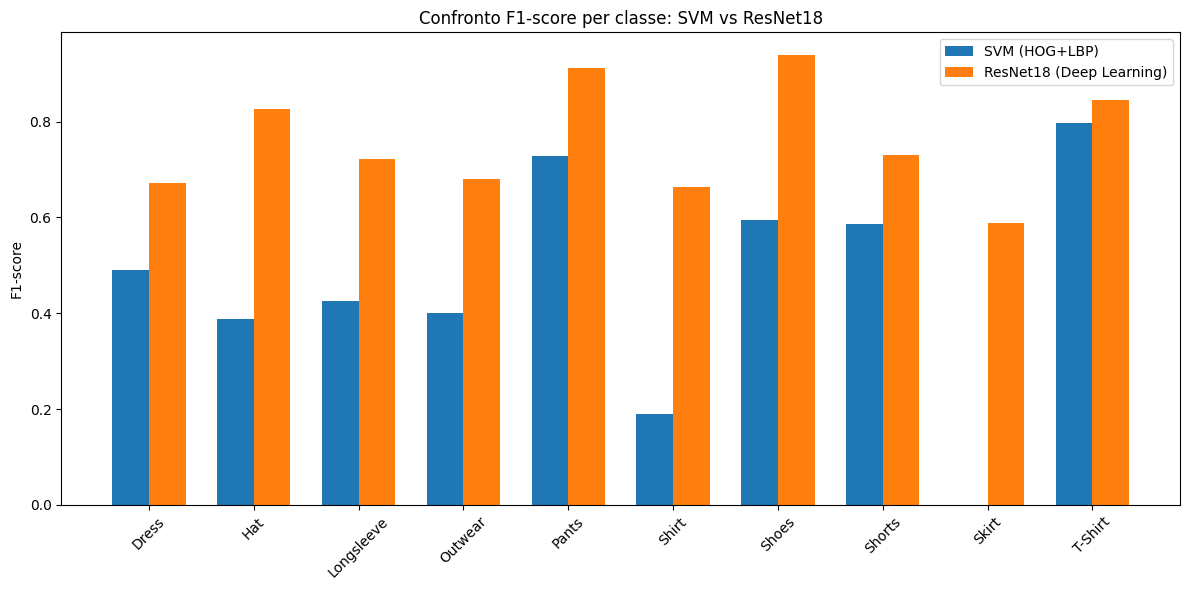

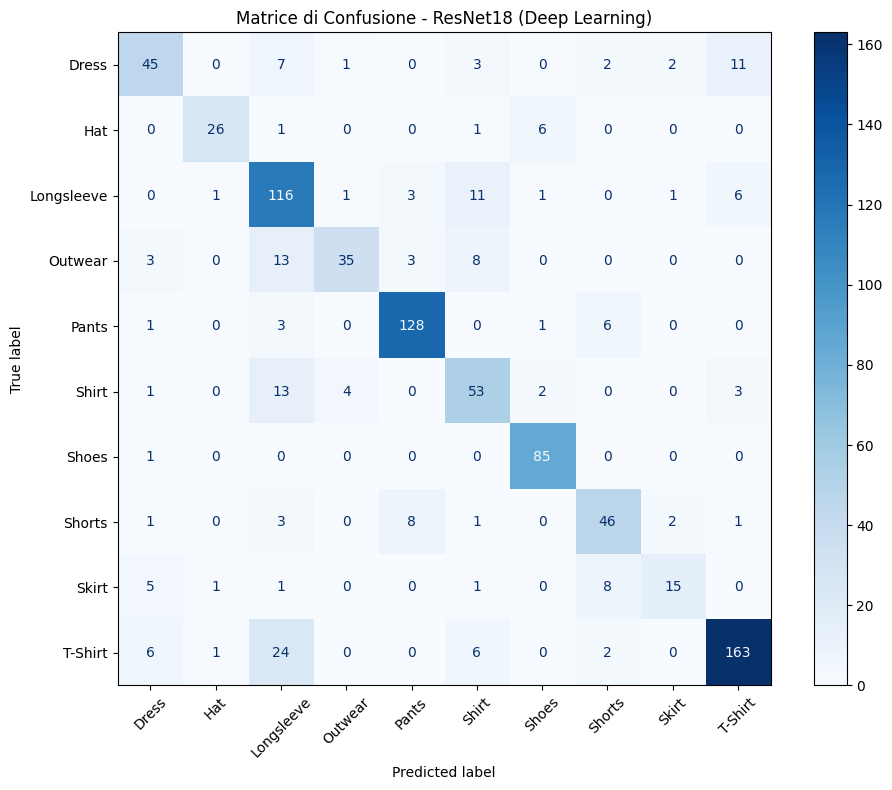


--- JSON OUTPUT PER INGESTION BACKEND ---
{
    "predicted_category": "Shoes",
    "confidence": 0.4127,
    "dominant_color_hex": "#d0c7bf",
    "dominant_color_rgb": [
        208,
        199,
        191
    ],
    "avg_inference_latency_ms": 107.53
}


In [8]:
# ==============================================================================
# FASE 6: Valutazione Comparativa e Pipeline di Inferenza JSON
# ==============================================================================
import json
import time
import pandas as pd
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_fscore_support, accuracy_score)

# ------------------------------------------------------------------
# 1. Metriche del modello Deep Learning (ResNet18) sul validation set
# ------------------------------------------------------------------
resnet.eval()
all_preds, all_targets = [], []

start_time = time.time()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = resnet(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())
dl_inference_duration = (time.time() - start_time) / len(val_dataset)

dl_pred_labels = [idx_to_label[p] for p in all_preds]
dl_true_labels = [idx_to_label[t] for t in all_targets]

dl_acc = accuracy_score(dl_true_labels, dl_pred_labels)
dl_prec, dl_rec, dl_f1, _ = precision_recall_fscore_support(
    dl_true_labels, dl_pred_labels, labels=unique_labels, zero_division=0
)
dl_macro_f1 = dl_f1.mean()

# ------------------------------------------------------------------
# 2. Metriche del modello Classico (SVM) - riusiamo y_test/y_pred_svm da Fase 4
# ------------------------------------------------------------------
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec, svm_rec, svm_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, labels=unique_labels, zero_division=0
)
svm_macro_f1 = svm_f1.mean()

# Tempo del solo classificatore (feature gia' estratte e scalate)
t0 = time.time()
_ = svm_model.predict(X_test_scaled)
svm_classifier_only_ms = (time.time() - t0) / len(X_test_scaled) * 1000

# Tempo dell'intera pipeline classica (segmentazione + HOG/LBP + SVM),
# misurato su un piccolo campione: e' il confronto onesto da fare con la
# latenza della ResNet, che include gia' caricamento + resize + forward pass.
# Il classificatore SVM da solo e' velocissimo: il costo vero sta
# nell'estrazione delle feature HOG/LBP a monte.
timing_sample = sample_subset.sample(min(20, len(sample_subset)), random_state=42)
pipeline_times = []
for _, row in timing_sample.iterrows():
    t0 = time.time()
    orig, seg, msk = segment_and_preprocess(row['filepath'])
    if orig is not None:
        feat = extract_classical_features(orig, msk).reshape(1, -1)
        feat_scaled = scaler.transform(feat)
        _ = svm_model.predict(feat_scaled)
    pipeline_times.append(time.time() - t0)
svm_full_pipeline_ms = (sum(pipeline_times) / len(pipeline_times)) * 1000

# ------------------------------------------------------------------
# 3. Tabella comparativa
# ------------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Modello": ["SVM (HOG+LBP)", "ResNet18 (Deep Learning)"],
    "Accuracy": [round(svm_acc, 4), round(dl_acc, 4)],
    "Macro F1-score": [round(svm_macro_f1, 4), round(dl_macro_f1, 4)],
    "Latenza classificatore (ms/img)": [round(svm_classifier_only_ms, 3), round(dl_inference_duration * 1000, 3)],
    "Latenza pipeline completa (ms/img)": [round(svm_full_pipeline_ms, 2), round(dl_inference_duration * 1000, 3)],
})

print("=== TABELLA COMPARATIVA: SVM vs ResNet18 ===")
print(comparison_df.to_string(index=False))

# Confronto per-classe (F1-score), stesso ordine di classi per entrambi i modelli
per_class_df = pd.DataFrame({
    "Classe": unique_labels,
    "F1 SVM": np.round(svm_f1, 3),
    "F1 ResNet18": np.round(dl_f1, 3),
})
print("\n=== F1-SCORE PER CLASSE: SVM vs ResNet18 ===")
print(per_class_df.to_string(index=False))

# Grafico comparativo per-classe
x = np.arange(len(unique_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, svm_f1, width, label="SVM (HOG+LBP)")
ax.bar(x + width/2, dl_f1, width, label="ResNet18 (Deep Learning)")
ax.set_xticks(x)
ax.set_xticklabels(unique_labels, rotation=45)
ax.set_ylabel("F1-score")
ax.set_title("Confronto F1-score per classe: SVM vs ResNet18")
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4. Matrice di Confusione (ResNet18)
# ------------------------------------------------------------------
cm = confusion_matrix(dl_true_labels, dl_pred_labels, labels=unique_labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Matrice di Confusione - ResNet18 (Deep Learning)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Pipeline di Inferenza End-to-End (JSON)
# ------------------------------------------------------------------
def predict_fashion_item(image_path):
    """
    Pipeline End-to-End di inferenza per integrare l'AI con il Backend.
    Restituisce un dizionario JSON strutturato con categoria, colore dominante e metriche.
    """
    orig, seg, mask = segment_and_preprocess(image_path)
    if orig is None:
        return {"error": "Immagine non valida o non trovata"}

    # 1. Estrazione Colore Dominante con K-Means
    hex_color, rgb_val = extract_dominant_color(seg, mask)
    rgb_clean = [int(c) for c in rgb_val]

    # 2. Classificazione Categoria con ResNet18
    pil_img = Image.open(image_path).convert('RGB')
    tensor_img = val_transforms(pil_img).unsqueeze(0).to(device)

    resnet.eval()
    with torch.no_grad():
        outputs = resnet(tensor_img)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    predicted_label = str(idx_to_label[pred_idx.item()])
    confidence_score = float(round(conf.item(), 4))

    # 3. Composizione Payload JSON
    payload = {
        "predicted_category": predicted_label,
        "confidence": confidence_score,
        "dominant_color_hex": str(hex_color),
        "dominant_color_rgb": rgb_clean,
        "avg_inference_latency_ms": float(round(dl_inference_duration * 1000, 2))
    }

    return payload

# Test di inferenza su un'immagine di prova
sample_test_path = val_df.iloc[0]['filepath']
result_json = predict_fashion_item(sample_test_path)

print("\n--- JSON OUTPUT PER INGESTION BACKEND ---")
print(json.dumps(result_json, indent=4))
